In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving baseline_results.csv to baseline_results.csv


In [ ]:
csv_baselinetextpost = "baseline_results.csv"
df = pd.read_csv(csv_baselinetextpost)

df.head()

,browser,text_type,condition,post_ms,total_ms
0,Google Chrome,Short,baseline_text_post,80,80
1,Google Chrome,Short,baseline_text_post,73,73
2,Google Chrome,Short,baseline_text_post,78,78
3,Google Chrome,Medium,baseline_text_post,80,80
4,Google Chrome,Medium,baseline_text_post,67,67


In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nUnique browsers:", df["browser"].unique())
print("\nUnique text types:", df["text_type"].unique())
print("\nUnique conditions:", df["condition"].unique())

display(df)

Shape: (18, 5)

Columns: ['browser', 'text_type', 'condition', 'post_ms', 'total_ms']

Unique browsers: ['Google Chrome' 'Firefox']

Unique text types: ['Short' 'Medium' 'Long']

Unique conditions: ['baseline_text_post']


,browser,text_type,condition,post_ms,total_ms
0,Google Chrome,Short,baseline_text_post,80,80
1,Google Chrome,Short,baseline_text_post,73,73
2,Google Chrome,Short,baseline_text_post,78,78
3,Google Chrome,Medium,baseline_text_post,80,80
4,Google Chrome,Medium,baseline_text_post,67,67
5,Google Chrome,Medium,baseline_text_post,72,72
6,Google Chrome,Long,baseline_text_post,130,130
7,Google Chrome,Long,baseline_text_post,56,56
8,Google Chrome,Long,baseline_text_post,71,71
9,Firefox,Short,baseline_text_post,154,154


In [ ]:
df["post_ms"] = pd.to_numeric(df["post_ms"], errors="coerce")
df["total_ms"] = pd.to_numeric(df["total_ms"], errors="coerce")

print(df.dtypes)

browser      object
text_type    object
condition    object
post_ms       int64
total_ms      int64
dtype: object


In [ ]:
overall_summary = df[["post_ms", "total_ms"]].agg(["mean", "median", "std", "min", "max"]).T
overall_summary

,mean,median,std,min,max
post_ms,93.666667,83.5,30.905929,56.0,159.0
total_ms,93.666667,83.5,30.905929,56.0,159.0


In [ ]:
overall_summary.to_csv("baseline_overall_summary.csv")

In [ ]:
browser_summary = df.groupby("browser")[["post_ms", "total_ms"]].agg(["mean", "median", "std", "min", "max"])
browser_summary

post_ms                               total_ms         \
                     mean median        std min  max        mean median   
browser                                                                   
Firefox        108.777778   90.0  32.984003  72  159  108.777778   90.0   
Google Chrome   78.555556   73.0  20.688832  56  130   78.555556   73.0   

                                   
                     std min  max  
browser                            
Firefox        32.984003  72  159  
Google Chrome  20.688832  56  130

In [ ]:
browser_summary.to_csv("baseline_browser_summary.csv")

In [ ]:
text_type_summary = df.groupby("text_type")[["post_ms", "total_ms"]].agg(["mean", "median", "std", "min", "max"])
text_type_summary

post_ms                              total_ms                    \
                mean median        std min  max       mean median        std   
text_type                                                                      
Long       93.333333   81.0  34.569736  56  141  93.333333   81.0  34.569736   
Medium     94.333333   84.5  33.714487  67  159  94.333333   84.5  33.714487   
Short      93.333333   83.5  30.250069  73  154  93.333333   83.5  30.250069   

                    
          min  max  
text_type           
Long       56  141  
Medium     67  159  
Short      73  154

In [ ]:
text_type_summary.to_csv("baseline_text_type_summary.csv")

In [ ]:
browser_text_summary = df.groupby(["browser", "text_type"])[["post_ms", "total_ms"]].agg(["mean", "median", "std", "min", "max"])
browser_text_summary

post_ms                               total_ms  \
                               mean median        std min  max        mean   
browser       text_type                                                      
Firefox       Long       101.000000   90.0  35.791060  72  141  101.000000   
              Medium     115.666667   99.0  37.859389  89  159  115.666667   
              Short      109.666667   88.0  38.397048  87  154  109.666667   
Google Chrome Long        85.666667   71.0  39.119475  56  130   85.666667   
              Medium      73.000000   72.0   6.557439  67   80   73.000000   
              Short       77.000000   78.0   3.605551  73   80   77.000000   

                                                    
                        median        std min  max  
browser       text_type                             
Firefox       Long        90.0  35.791060  72  141  
              Medium      99.0  37.859389  89  159  
              Short       88.0  38.397048  87  154  
Google Chrome Long        71.0  39.119475  56  130  
              Medium      72.0   6.557439  67   80  
              Short       78.0   3.605551  73   80

In [ ]:
browser_text_summary.to_csv("baseline_browser_text_summary.csv")

In [ ]:
recap_table = df.groupby(["browser", "text_type"])[["post_ms", "total_ms"]].mean().round(2).reset_index()
recap_table

,browser,text_type,post_ms,total_ms
0,Firefox,Long,101.00,101.00
1,Firefox,Medium,115.67,115.67
2,Firefox,Short,109.67,109.67
3,Google Chrome,Long,85.67,85.67
4,Google Chrome,Medium,73.00,73.00
5,Google Chrome,Short,77.00,77.00


In [ ]:
recap_table.to_csv("baseline_recap_table.csv", index=False)

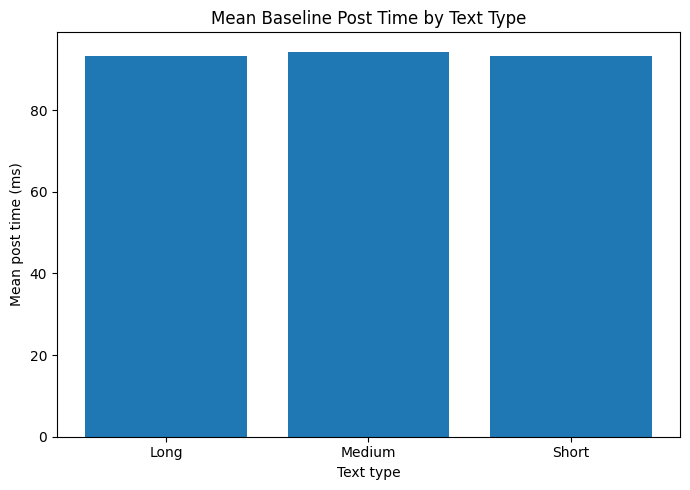

In [ ]:
import matplotlib.pyplot as plt

mean_post_by_text = df.groupby("text_type")["post_ms"].mean()

plt.figure(figsize=(7,5))
plt.bar(mean_post_by_text.index, mean_post_by_text.values)
plt.xlabel("Text type")
plt.ylabel("Mean post time (ms)")
plt.title("Mean Baseline Post Time by Text Type")
plt.tight_layout()
plt.show()

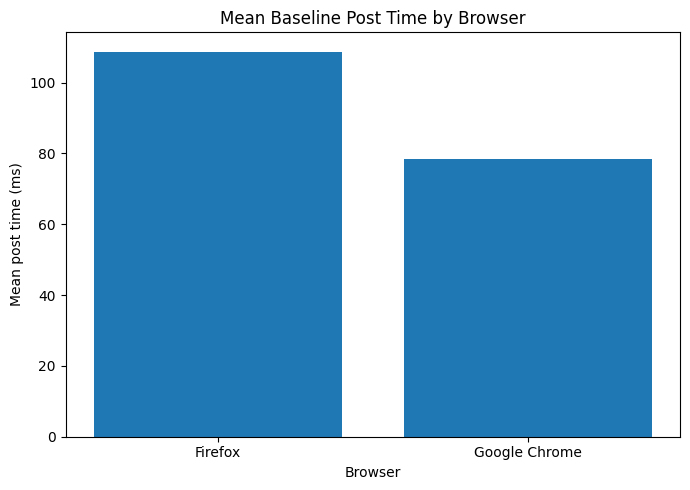

In [ ]:
mean_post_by_browser = df.groupby("browser")["post_ms"].mean()

plt.figure(figsize=(7,5))
plt.bar(mean_post_by_browser.index, mean_post_by_browser.values)
plt.xlabel("Browser")
plt.ylabel("Mean post time (ms)")
plt.title("Mean Baseline Post Time by Browser")
plt.tight_layout()
plt.show()

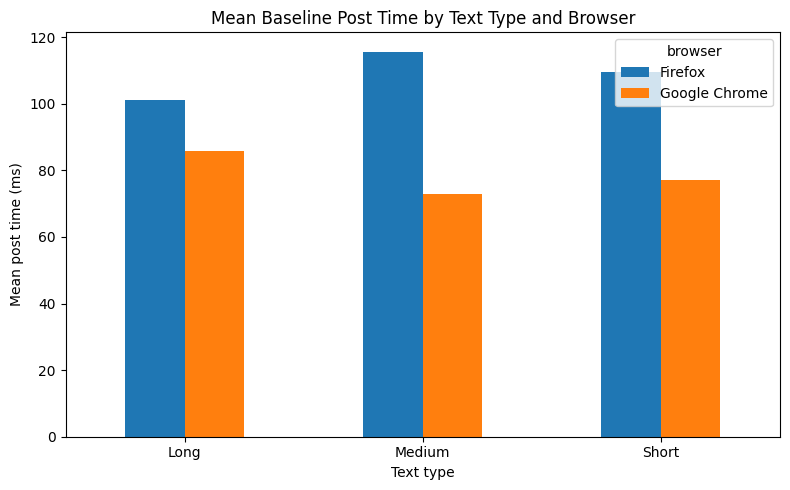

In [ ]:
pivot_post = df.pivot_table(index="text_type", columns="browser", values="post_ms", aggfunc="mean")

pivot_post.plot(kind="bar", figsize=(8,5))
plt.xlabel("Text type")
plt.ylabel("Mean post time (ms)")
plt.title("Mean Baseline Post Time by Text Type and Browser")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5707/743154134.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=text_types)


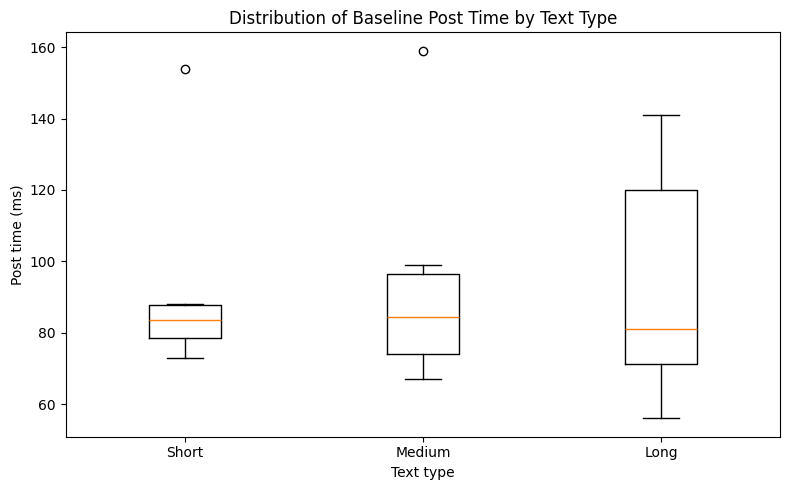

In [ ]:
text_types = df["text_type"].unique()

data = [df[df["text_type"] == t]["post_ms"].dropna() for t in text_types]

plt.figure(figsize=(8,5))
plt.boxplot(data, labels=text_types)
plt.xlabel("Text type")
plt.ylabel("Post time (ms)")
plt.title("Distribution of Baseline Post Time by Text Type")
plt.tight_layout()
plt.show()

/tmp/ipykernel_5707/2259157706.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=browsers)


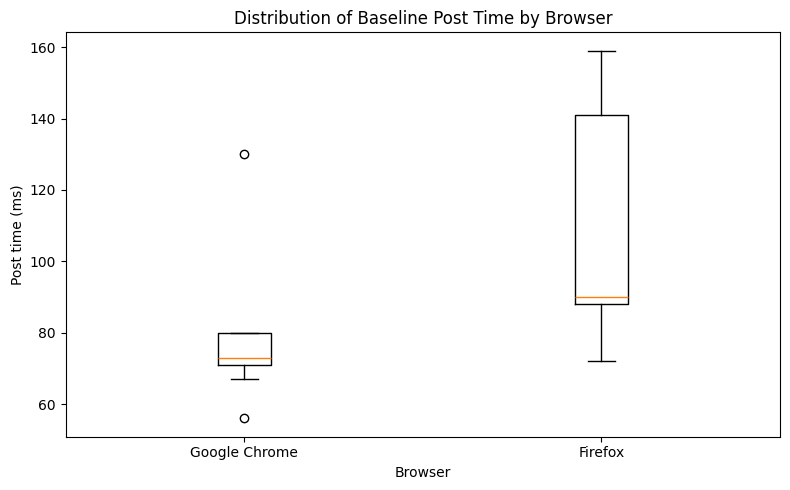

In [ ]:
browsers = df["browser"].unique()

data = [df[df["browser"] == b]["post_ms"].dropna() for b in browsers]

plt.figure(figsize=(8,5))
plt.boxplot(data, labels=browsers)
plt.xlabel("Browser")
plt.ylabel("Post time (ms)")
plt.title("Distribution of Baseline Post Time by Browser")
plt.tight_layout()
plt.show()